# Retriever Goldilocks: TechQA (RAGBench)

Same three-phase retriever search methodology as `delucion_dataset/12_retriever_goldilocks.ipynb`,
applied to TechQA on top of `11`'s real TechQA chunking winner -- **recursive-character
chunking, 128-token nominal target (~90 actual tokens/chunk), 10% overlap** (composite
0.401, the best of 17 configs tested across method/size/overlap sweeps for TechQA). This is
notably not DelucionQA's chunking winner (sentence + metadata @ 64t) -- `11`'s TechQA
analysis found sentence-aware chunking was TechQA's *worst* performer, since forum-thread
text doesn't segment into clean sentences the way manual prose does. Retrieval is this
notebook's own independent variable, built on top of that dataset-specific chunking layer,
not assumed to inherit DelucionQA's retrieval answer either.

Same rigor as the DelucionQA series: fixed 20-question evaluation set reused across every
config, judge annotation retries, and the same composite score (0.35·Relevance +
0.15·Utilization + 0.15·Completeness + 0.35·Adherence) for direct comparability across
datasets.


## Step 1: Install Dependencies

In [1]:
!pip install -q python-dotenv datasets tiktoken langchain-core langchain-text-splitters langchain-huggingface langchain-chroma langchain-openai nltk matplotlib rank-bm25


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


## Step 2: Imports & Setup

In [2]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from rank_bm25 import BM25Okapi
from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()
openrouter_token = os.environ.get("OPENROUTER_TOKEN")

import sys


def _add_ragbench_lib_to_path():
    """ragbench_lib physically lives under delucion_dataset/ -- shared, not
    duplicated, across every dataset folder in this repo."""
    here = os.getcwd()
    candidates = (
        here,
        os.path.join(here, "delucion_dataset"),
        os.path.join(os.path.dirname(here), "delucion_dataset"),
        os.path.join(here, "..", "delucion_dataset"),
    )
    for candidate in candidates:
        candidate = os.path.abspath(candidate)
        if os.path.isdir(os.path.join(candidate, "ragbench_lib")) and candidate not in sys.path:
            sys.path.insert(0, candidate)
            return
    raise RuntimeError("Could not locate the shared ragbench_lib package (expected under delucion_dataset/).")


_add_ragbench_lib_to_path()

from ragbench_lib.data_loading import load_rag_bench_data
from ragbench_lib.models import get_embedding_model, get_generation_llm, get_judge_llm
from ragbench_lib.generation_prompt import RAG_GENERATION_PROMPT
from ragbench_lib.vector_store import get_persist_dir, vector_store_names
from ragbench_lib.chunking import count_tokens, get_sentences
from ragbench_lib.trace_eval import (
    annotate_response_for_metrics_with_retry,
    compute_context_relevance,
    compute_utilization,
    compute_completeness,
    compute_adherence,
)

print("✓ All imports successful")


/Users/saikrishna/Desktop/Codespace/IIIT_AI_ML_course/Capstone_Project/reliablerag/.venv-1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports successful


## Step 3: Load Dataset (fixed evaluation set)

`EVAL_SAMPLE_SIZE` questions are chosen **once**, up front, and reused for every single
config below -- Phase 1, 2, and 3 all score against the exact same questions, so
differences between configs reflect the retriever choice, not sampling luck. Same
mechanism `11_chunking_goldilocks.ipynb` used for chunking.

In [3]:
DATASET_NAME = "techqa"  # feeds load_rag_bench_data() and vector store naming -- RAGBench's tech-forum Q&A config
EVAL_SAMPLE_SIZE = 20        # fixed across every config in this notebook

print("Loading dataset...")
docs_df = load_rag_bench_data(DATASET_NAME, num_samples=max(EVAL_SAMPLE_SIZE + 10, 30))
print(f"✓ Loaded {len(docs_df)} documents from {docs_df['row_id'].nunique()} unique questions")

eval_questions_df = docs_df.drop_duplicates(subset=["row_id"]).head(EVAL_SAMPLE_SIZE).reset_index(drop=True)
print(f"✓ Fixed evaluation set: {len(eval_questions_df)} unique questions (reused for every config below)")


Loading dataset...
✓ Loaded 150 documents from 30 unique questions
✓ Fixed evaluation set: 20 unique questions (reused for every config below)


## Step 4: Models

In [4]:
embedding_model = get_embedding_model(openrouter_token)
llm = get_generation_llm(openrouter_token)
llama_judge = get_judge_llm(openrouter_token)
prompt = RAG_GENERATION_PROMPT

print("✓ Embedding model, generator, and judge configured")


✓ Embedding model, generator, and judge configured


## Step 5: Fixed Chunking Foundation

Every retriever config below is built on `11_chunking_goldilocks.ipynb`'s winning TechQA
chunking configuration -- **recursive-character chunking, 128-token nominal target (~90
actual tokens/chunk), 10% overlap** (composite 0.401, the best of 17 configs tested for
TechQA). This notebook's independent variable is the retriever, not the chunker, so the
chunking layer is held fixed at its own TechQA-specific best-known config.

In [5]:
CHUNK_TARGET_TOKENS = 128
CHUNK_OVERLAP_FRACTION = 0.10


def recursive_character_chunks(docs_df, target_tokens=128, overlap_fraction=0.1):
    """LangChain's standard RecursiveCharacterTextSplitter -- 11's TechQA winner.
    ~4 chars/token heuristic converts the token budget into the character-based
    splitter's units (same heuristic 11 used to find this winning config)."""
    chunk_size_chars = target_tokens * 4
    overlap_chars = int(chunk_size_chars * overlap_fraction)
    splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size_chars, chunk_overlap=overlap_chars)
    documents = []
    for _, doc in docs_df.iterrows():
        for chunk_idx, chunk_text in enumerate(splitter.split_text(doc["text"])):
            if chunk_text.strip():
                documents.append(Document(
                    page_content=chunk_text,
                    metadata={
                        "chunk_id": f"{doc['doc_id']}_rc{chunk_idx}",
                        "row_id": doc["row_id"],
                        "tokens": count_tokens(chunk_text),
                    },
                ))
    return documents


print("Building fixed chunking foundation (recursive_char, 128t nominal, 10% overlap)...")
documents = recursive_character_chunks(docs_df, target_tokens=CHUNK_TARGET_TOKENS, overlap_fraction=CHUNK_OVERLAP_FRACTION)
print(f"✓ Built {len(documents)} chunks, avg {np.mean([d.metadata['tokens'] for d in documents]):.0f} tokens/chunk")


Building fixed chunking foundation (recursive_char, 128t nominal, 10% overlap)...
✓ Built 1649 chunks, avg 90 tokens/chunk


## Step 6: Retriever Implementations

Four retrieval strategies from the paper's search space, each exposing the parameter this
notebook sweeps once its phase comes up:

- **similarity** -- plain dense cosine similarity (no extra tunable parameter beyond `k`)
- **mmr** -- dense retrieval with Maximal Marginal Relevance (`lambda_mult`: 1.0 = pure
  relevance, 0.0 = pure diversity)
- **bm25** -- sparse lexical retrieval (no extra tunable parameter beyond `k`)
- **hybrid** -- BM25 + dense, linearly combined (`alpha`: weight on the BM25 side, so
  `alpha=1.0` is pure BM25 and `alpha=0.0` is pure dense)

All four take `documents` (the fixed chunking foundation above) and share a `.retrieve(query)`
interface so the evaluation runner in Step 7 can treat them identically.

In [6]:
class SimilarityRetriever:
    """Plain dense cosine similarity search."""

    def __init__(self, documents, embedding_model, k=8, config_name="sim"):
        self.k = k
        prefix, collection_name = vector_store_names(DATASET_NAME, config_name)
        persist_dir = get_persist_dir(prefix)
        self.vector_store = Chroma.from_documents(
            documents=documents, embedding=embedding_model,
            collection_name=collection_name, persist_directory=persist_dir,
        )

    def retrieve(self, query):
        return self.vector_store.as_retriever(
            search_type="similarity", search_kwargs={"k": self.k}
        ).invoke(query)


class MMRRetriever:
    """Dense retrieval with Maximal Marginal Relevance -- balances relevance & diversity."""

    def __init__(self, documents, embedding_model, k=8, lambda_mult=0.5, config_name="mmr"):
        self.k = k
        self.lambda_mult = lambda_mult
        prefix, collection_name = vector_store_names(DATASET_NAME, config_name)
        persist_dir = get_persist_dir(prefix)
        self.vector_store = Chroma.from_documents(
            documents=documents, embedding=embedding_model,
            collection_name=collection_name, persist_directory=persist_dir,
        )

    def retrieve(self, query):
        return self.vector_store.as_retriever(
            search_type="mmr",
            search_kwargs={"k": self.k, "lambda_mult": self.lambda_mult},
        ).invoke(query)


class BM25Retriever:
    """Sparse lexical retrieval baseline -- no embedding calls at query time."""

    def __init__(self, documents, k=8, **_ignored):
        self.k = k
        self.documents = documents
        tokenized = [d.page_content.split() for d in documents]
        self.bm25 = BM25Okapi(tokenized)

    def retrieve(self, query):
        scores = self.bm25.get_scores(query.split())
        top_indices = np.argsort(scores)[-self.k:][::-1]
        return [self.documents[i] for i in top_indices]


class HybridRetriever:
    """BM25 + dense similarity, linearly combined after min-max normalizing each side.
    `alpha` is the weight on BM25; `(1 - alpha)` is the weight on the normalized dense score."""

    def __init__(self, documents, embedding_model, k=8, alpha=0.5, config_name="hybrid"):
        self.k = k
        self.alpha = alpha
        self.documents = documents
        tokenized = [d.page_content.split() for d in documents]
        self.bm25 = BM25Okapi(tokenized)

        prefix, collection_name = vector_store_names(DATASET_NAME, config_name)
        persist_dir = get_persist_dir(prefix)
        self.vector_store = Chroma.from_documents(
            documents=documents, embedding=embedding_model,
            collection_name=collection_name, persist_directory=persist_dir,
        )

    def retrieve(self, query):
        bm25_scores = np.array(self.bm25.get_scores(query.split()), dtype=float)
        if np.max(bm25_scores) > np.min(bm25_scores):
            bm25_scores = (bm25_scores - np.min(bm25_scores)) / (np.max(bm25_scores) - np.min(bm25_scores))
        else:
            bm25_scores = np.ones_like(bm25_scores) / max(len(bm25_scores), 1)

        dense_results = self.vector_store.similarity_search_with_score(query, k=len(self.documents))
        dense_score_by_content = {}
        if dense_results:
            raw = np.array([score for _, score in dense_results], dtype=float)
            if np.max(raw) > np.min(raw):
                norm = 1.0 - (raw - np.min(raw)) / (np.max(raw) - np.min(raw))
            else:
                norm = np.ones_like(raw)
            for (doc, _), score in zip(dense_results, norm):
                dense_score_by_content[doc.page_content] = score

        combined = np.array([
            self.alpha * bm25_scores[i] + (1 - self.alpha) * dense_score_by_content.get(d.page_content, 0.0)
            for i, d in enumerate(self.documents)
        ])
        top_indices = np.argsort(combined)[-self.k:][::-1]
        return [self.documents[i] for i in top_indices]


print("✓ Retriever implementations ready (similarity, mmr, bm25, hybrid)")


✓ Retriever implementations ready (similarity, mmr, bm25, hybrid)


## Step 7: Evaluation Runner

One function used by every phase below: builds/wraps a retriever, runs the fixed question
set through it, retries failed judge annotations instead of dropping them, and reports both
raw TRACe metrics and the same documented composite score `11_chunking_goldilocks.ipynb`
used.

**Composite score = 0.35·Relevance + 0.15·Utilization + 0.15·Completeness + 0.35·Adherence**
(identical weighting to `11`, for direct comparability -- Relevance and Adherence weighted
highest since they carry the most direct practical consequence: how much irrelevant text
the retriever hands over, and how often the generator hallucinates as a result).

In [7]:
def evaluate_retriever_config(config_name, retriever, eval_questions_df, max_annotate_attempts=3):
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = (
        {"context": lambda q: format_docs(retriever.retrieve(q)), "question": lambda q: q}
        | prompt | llm | StrOutputParser()
    )

    per_sample = []
    n_failed = 0
    retrieved_counts = []
    for _, row in eval_questions_df.iterrows():
        question = row["question"]
        try:
            response = rag_chain.invoke(question)
            retrieved_docs = retriever.retrieve(question)
            retrieved_texts = [d.page_content for d in retrieved_docs]
            retrieved_counts.append(len(retrieved_texts))
            annotation = annotate_response_for_metrics_with_retry(
                llama_judge, retrieved_texts, question, response, max_attempts=max_annotate_attempts
            )
            if annotation["success"]:
                per_sample.append({
                    "context_relevance": compute_context_relevance(retrieved_texts, annotation),
                    "utilization": compute_utilization(retrieved_texts, annotation),
                    "completeness": compute_completeness(annotation),
                    "adherence": compute_adherence(annotation),
                })
            else:
                n_failed += 1
        except Exception:
            n_failed += 1

    result = {
        "config": config_name,
        "avg_retrieved": round(float(np.mean(retrieved_counts)), 1) if retrieved_counts else 0.0,
        "n_eval": len(per_sample),
        "n_failed": n_failed,
        "context_relevance": np.mean([r["context_relevance"] for r in per_sample]) if per_sample else None,
        "utilization": np.mean([r["utilization"] for r in per_sample]) if per_sample else None,
        "completeness": np.mean([r["completeness"] for r in per_sample]) if per_sample else None,
        "adherence": np.mean([r["adherence"] for r in per_sample]) if per_sample else None,
    }
    if per_sample:
        result["composite"] = (
            0.35 * result["context_relevance"]
            + 0.15 * result["utilization"]
            + 0.15 * result["completeness"]
            + 0.35 * result["adherence"]
        )
    else:
        result["composite"] = None
    return result


print("✓ evaluate_retriever_config defined")


✓ evaluate_retriever_config defined


## Step 8: Phase 1 -- Retrieval Method Comparison (fixed k=8)

Every method below runs at the same `k=8` (the depth `11` and the original paper held
fixed), so this phase isolates **retrieval method**, not depth. MMR and hybrid use their
own default tuning value (`lambda_mult=0.5`, `alpha=0.5`) here -- their own knob gets swept
in Phase 3.

In [8]:
K_PHASE1 = 8

phase1_builders = {
    "similarity": lambda: SimilarityRetriever(documents, embedding_model, k=K_PHASE1, config_name="p1_similarity"),
    "mmr": lambda: MMRRetriever(documents, embedding_model, k=K_PHASE1, lambda_mult=0.5, config_name="p1_mmr"),
    "bm25": lambda: BM25Retriever(documents, k=K_PHASE1),
    "hybrid": lambda: HybridRetriever(documents, embedding_model, k=K_PHASE1, alpha=0.5, config_name="p1_hybrid"),
}

print("=" * 100)
print(f"PHASE 1: RETRIEVAL METHOD COMPARISON @ k={K_PHASE1}, {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase1_results = []
for name, builder in phase1_builders.items():
    print(f"\n--- {name} ---")
    retriever = builder()
    result = evaluate_retriever_config(f"p1_{name}", retriever, eval_questions_df)
    phase1_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Util={result['utilization']:.4f} "
              f"Comp={result['completeness']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase1_df = pd.DataFrame(phase1_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 1 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase1_df)


PHASE 1: RETRIEVAL METHOD COMPARISON @ k=8, 20 fixed questions

--- similarity ---
  CR=0.1790 Util=0.1027 Comp=0.4300 Adh=0.5500 Composite=0.3350  (failed 0/20)

--- mmr ---
  CR=0.2112 Util=0.1361 Comp=0.6567 Adh=0.6500 Composite=0.4203  (failed 0/20)

--- bm25 ---
  CR=0.2465 Util=0.1004 Comp=0.4801 Adh=0.5000 Composite=0.3484  (failed 0/20)

--- hybrid ---
  CR=0.2220 Util=0.1192 Comp=0.5289 Adh=0.5500 Composite=0.3674  (failed 0/20)

PHASE 1 RESULTS (ranked by composite score)


,config,avg_retrieved,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
1,p1_mmr,8.0,20,0,0.211195,0.136130,0.656670,0.65,0.420338
3,p1_hybrid,8.0,20,0,0.221995,0.119160,0.528860,0.55,0.367401
2,p1_bm25,8.0,20,0,0.246485,0.100425,0.480120,0.50,0.348351
0,p1_similarity,8.0,20,0,0.178970,0.102715,0.429995,0.55,0.335046


## Step 9: Phase 2 -- Retrieval Depth (`k`) Sweep

Takes Phase 1's winning method and sweeps `k`, holding method (and its own tuning
parameter, at the Phase 1 default) fixed -- isolates **retrieval depth**, unconfounded
with method choice. This is the interaction `11_chunking_goldilocks.ipynb` explicitly
flagged as out of scope (chunk size x k) -- here `k` is finally swept on its own axis.

In [9]:
PHASE2_METHOD_BUILDERS = {
    "similarity": lambda k, cfg: SimilarityRetriever(documents, embedding_model, k=k, config_name=cfg),
    "mmr": lambda k, cfg: MMRRetriever(documents, embedding_model, k=k, lambda_mult=0.5, config_name=cfg),
    "bm25": lambda k, cfg: BM25Retriever(documents, k=k),
    "hybrid": lambda k, cfg: HybridRetriever(documents, embedding_model, k=k, alpha=0.5, config_name=cfg),
}

phase1_winner = phase1_df.iloc[0]["config"].replace("p1_", "")
builder_fn = PHASE2_METHOD_BUILDERS[phase1_winner]
print(f"Phase 1 winner: {phase1_winner} -- sweeping k next\n")

k_values_to_test = [4, 6, 8, 10, 12, 16]

print("=" * 100)
print(f"PHASE 2: K SWEEP for '{phase1_winner}' retrieval, {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase2_results = []
for k in k_values_to_test:
    print(f"\n--- {phase1_winner} @ k={k} ---")
    retriever = builder_fn(k, f"p2_{phase1_winner}_k{k}")
    result = evaluate_retriever_config(f"p2_{phase1_winner}_k{k}", retriever, eval_questions_df)
    phase2_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase2_df = pd.DataFrame(phase2_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 2 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase2_df)


Phase 1 winner: mmr -- sweeping k next

PHASE 2: K SWEEP for 'mmr' retrieval, 20 fixed questions

--- mmr @ k=4 ---
  CR=0.2909 Adh=0.5500 Composite=0.4160  (failed 0/20)

--- mmr @ k=6 ---
  CR=0.2056 Adh=0.6500 Composite=0.4238  (failed 0/20)

--- mmr @ k=8 ---
  CR=0.1856 Adh=0.6500 Composite=0.3818  (failed 0/20)

--- mmr @ k=10 ---
  CR=0.1377 Adh=0.7000 Composite=0.3815  (failed 0/20)

--- mmr @ k=12 ---
  CR=0.1253 Adh=0.6500 Composite=0.3393  (failed 0/20)

--- mmr @ k=16 ---
  CR=0.0890 Adh=0.7000 Composite=0.3573  (failed 0/20)

PHASE 2 RESULTS (ranked by composite score)


,config,avg_retrieved,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
1,p2_mmr_k6,6.0,20,0,0.205590,0.137735,0.691130,0.65,0.423786
0,p2_mmr_k4,4.0,20,0,0.290945,0.179435,0.631660,0.55,0.415995
2,p2_mmr_k8,8.0,20,0,0.185640,0.106265,0.489050,0.65,0.381771
3,p2_mmr_k10,10.0,20,0,0.137715,0.082135,0.506845,0.70,0.381547
5,p2_mmr_k16,16.0,20,0,0.088995,0.049535,0.491705,0.70,0.357334
4,p2_mmr_k12,12.0,20,0,0.125345,0.055555,0.397500,0.65,0.339329


## Step 10: Phase 3 -- Method-Specific Parameter Sweep

Takes Phase 2's winning `k` and sweeps the winning method's own tuning knob, holding
method and `k` fixed -- isolates **that parameter** from everything else:

- `mmr` -> `lambda_mult` (1.0 = pure relevance ... 0.0 = pure diversity)
- `hybrid` -> `alpha` (1.0 = pure BM25 ... 0.0 = pure dense)
- `similarity` / `bm25` have no extra knob beyond `k` -- if either wins Phase 1, this phase
  falls back to sweeping `mmr`'s `lambda_mult` at the winning `k` instead, so Phase 3 always
  produces a usable parameter recommendation (mirrors `11`'s fallback when its Phase 1
  winner wasn't size-sweepable).

In [10]:
phase2_winner_config = phase2_df.iloc[0]["config"]
phase2_winner_k = int(phase2_winner_config.rsplit("_k", 1)[-1])
print(f"Phase 2 winner k: {phase2_winner_k} -- sweeping method-specific parameter next\n")

PHASE3_PARAM_SWEEPS = {
    "mmr": {
        "param_name": "lambda_mult",
        "values": [0.0, 0.25, 0.5, 0.75, 1.0],
        "build": lambda v, cfg: MMRRetriever(documents, embedding_model, k=phase2_winner_k, lambda_mult=v, config_name=cfg),
    },
    "hybrid": {
        "param_name": "alpha",
        "values": [0.1, 0.3, 0.5, 0.7, 0.9],
        "build": lambda v, cfg: HybridRetriever(documents, embedding_model, k=phase2_winner_k, alpha=v, config_name=cfg),
    },
}

phase3_method = phase1_winner if phase1_winner in PHASE3_PARAM_SWEEPS else "mmr"
if phase3_method != phase1_winner:
    print(f"Phase 1 winner '{phase1_winner}' has no extra tunable parameter beyond k; "
          f"falling back to sweeping mmr's lambda_mult @ k={phase2_winner_k} instead.\n")

sweep = PHASE3_PARAM_SWEEPS[phase3_method]
param_name, param_values, build_fn = sweep["param_name"], sweep["values"], sweep["build"]

print("=" * 100)
print(f"PHASE 3: {param_name.upper()} SWEEP for '{phase3_method}' @ k={phase2_winner_k}, {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase3_results = []
for v in param_values:
    print(f"\n--- {phase3_method} @ k={phase2_winner_k}, {param_name}={v} ---")
    retriever = build_fn(v, f"p3_{phase3_method}_k{phase2_winner_k}_{param_name}{v}")
    result = evaluate_retriever_config(f"p3_{phase3_method}_k{phase2_winner_k}_{param_name}{v}", retriever, eval_questions_df)
    phase3_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase3_df = pd.DataFrame(phase3_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 3 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase3_df)


Phase 2 winner k: 6 -- sweeping method-specific parameter next

PHASE 3: LAMBDA_MULT SWEEP for 'mmr' @ k=6, 20 fixed questions

--- mmr @ k=6, lambda_mult=0.0 ---
  CR=0.2004 Adh=0.4500 Composite=0.3149  (failed 0/20)

--- mmr @ k=6, lambda_mult=0.25 ---
  CR=0.1659 Adh=0.6000 Composite=0.3715  (failed 0/20)

--- mmr @ k=6, lambda_mult=0.5 ---
  CR=0.2517 Adh=0.6500 Composite=0.4435  (failed 0/20)

--- mmr @ k=6, lambda_mult=0.75 ---
  CR=0.2756 Adh=0.5500 Composite=0.3794  (failed 0/20)

--- mmr @ k=6, lambda_mult=1.0 ---
  CR=0.2214 Adh=0.6500 Composite=0.3967  (failed 0/20)

PHASE 3 RESULTS (ranked by composite score)


,config,avg_retrieved,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
2,p3_mmr_k6_lambda_mult0.5,6.0,20,0,0.251695,0.171665,0.680955,0.65,0.443486
4,p3_mmr_k6_lambda_mult1.0,6.0,20,0,0.221415,0.127665,0.483635,0.65,0.396690
3,p3_mmr_k6_lambda_mult0.75,6.0,20,0,0.275575,0.118610,0.484645,0.55,0.379440
1,p3_mmr_k6_lambda_mult0.25,6.0,20,0,0.165860,0.107380,0.582500,0.60,0.371533
0,p3_mmr_k6_lambda_mult0.0,6.0,20,0,0.200380,0.098740,0.482910,0.45,0.314881


## Step 11: Visualize the Sweeps

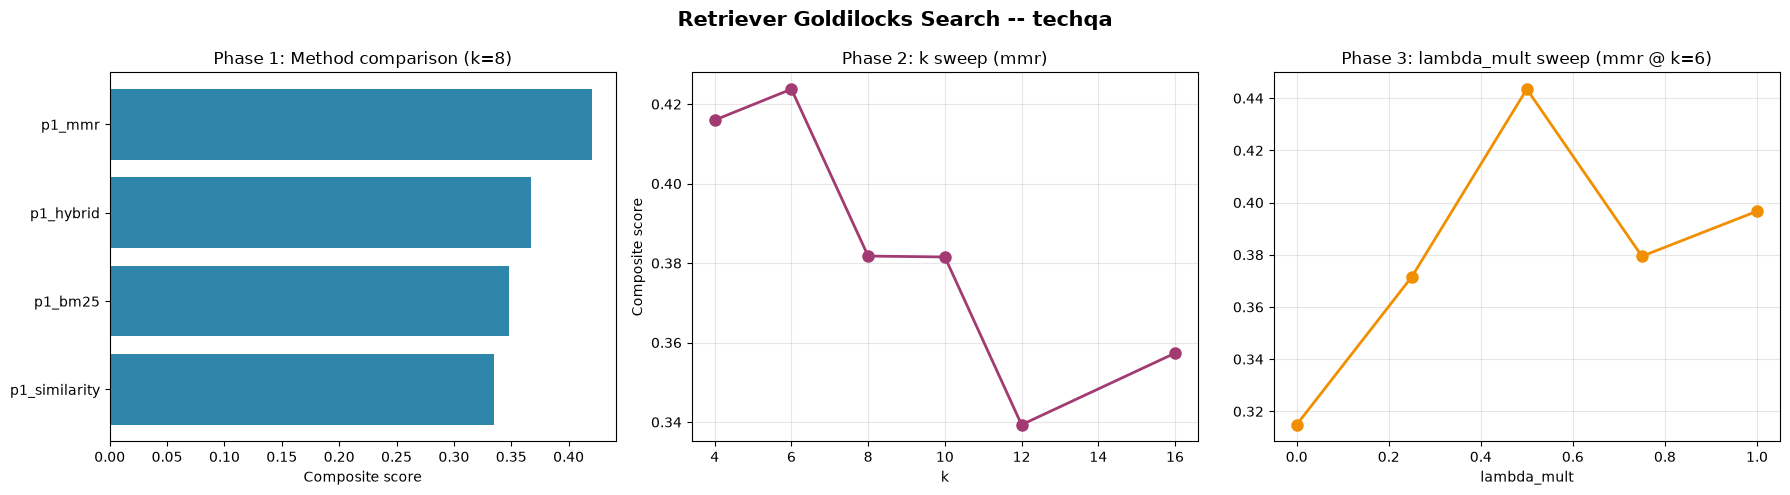

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Retriever Goldilocks Search -- {DATASET_NAME}", fontsize=15, fontweight="bold")

p1_plot = phase1_df.dropna(subset=["composite"]).sort_values("composite")
axes[0].barh(p1_plot["config"], p1_plot["composite"], color="#2E86AB")
axes[0].set_xlabel("Composite score")
axes[0].set_title(f"Phase 1: Method comparison (k={K_PHASE1})")

p2_plot = phase2_df.dropna(subset=["composite"]).copy()
p2_plot["k"] = p2_plot["config"].str.extract(r"_k(\d+)$").astype(int)
p2_plot = p2_plot.sort_values("k")
axes[1].plot(p2_plot["k"], p2_plot["composite"], "o-", color="#A23B72", linewidth=2, markersize=8)
axes[1].set_xlabel("k")
axes[1].set_ylabel("Composite score")
axes[1].set_title(f"Phase 2: k sweep ({phase1_winner})")
axes[1].grid(True, alpha=0.3)

p3_plot = phase3_df.dropna(subset=["composite"]).copy()
p3_plot["param_value"] = p3_plot["config"].str.extract(rf"_{param_name}([0-9.]+)$").astype(float)
p3_plot = p3_plot.sort_values("param_value")
axes[2].plot(p3_plot["param_value"], p3_plot["composite"], "o-", color="#F18F01", linewidth=2, markersize=8)
axes[2].set_xlabel(param_name)
axes[2].set_title(f"Phase 3: {param_name} sweep ({phase3_method} @ k={phase2_winner_k})")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 12: Final Recommendation

In [12]:
all_results_df = pd.concat([phase1_df, phase2_df, phase3_df], ignore_index=True)
all_results_df = all_results_df.dropna(subset=["composite"]).sort_values("composite", ascending=False)

print("=" * 100)
print("ALL CONFIGS ACROSS ALL THREE PHASES, RANKED BY COMPOSITE SCORE")
print("=" * 100)
display(all_results_df[[
    "config", "avg_retrieved", "n_eval", "n_failed",
    "context_relevance", "utilization", "completeness", "adherence", "composite",
]])

best = all_results_df.iloc[0]
print("\n" + "=" * 100)
print(f"🏆 GOLDILOCKS RETRIEVER CONFIG: {best['config']}")
print("=" * 100)
print(f"  Avg docs retrieved: {best['avg_retrieved']:.1f}")
print(f"  Context Relevance:  {best['context_relevance']:.4f}")
print(f"  Utilization:        {best['utilization']:.4f}")
print(f"  Completeness:       {best['completeness']:.4f}")
print(f"  Adherence:          {best['adherence']:.4f}")
print(f"  Composite:          {best['composite']:.4f}")
print(f"  Eval sample:        {best['n_eval']}/{EVAL_SAMPLE_SIZE} succeeded (failed: {best['n_failed']})")
print("=" * 100)


ALL CONFIGS ACROSS ALL THREE PHASES, RANKED BY COMPOSITE SCORE


,config,avg_retrieved,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
10,p3_mmr_k6_lambda_mult0.5,6.0,20,0,0.251695,0.171665,0.680955,0.65,0.443486
4,p2_mmr_k6,6.0,20,0,0.205590,0.137735,0.691130,0.65,0.423786
0,p1_mmr,8.0,20,0,0.211195,0.136130,0.656670,0.65,0.420338
5,p2_mmr_k4,4.0,20,0,0.290945,0.179435,0.631660,0.55,0.415995
11,p3_mmr_k6_lambda_mult1.0,6.0,20,0,0.221415,0.127665,0.483635,0.65,0.396690
6,p2_mmr_k8,8.0,20,0,0.185640,0.106265,0.489050,0.65,0.381771
7,p2_mmr_k10,10.0,20,0,0.137715,0.082135,0.506845,0.70,0.381547
12,p3_mmr_k6_lambda_mult0.75,6.0,20,0,0.275575,0.118610,0.484645,0.55,0.379440
13,p3_mmr_k6_lambda_mult0.25,6.0,20,0,0.165860,0.107380,0.582500,0.60,0.371533
1,p1_hybrid,8.0,20,0,0.221995,0.119160,0.528860,0.55,0.367401



🏆 GOLDILOCKS RETRIEVER CONFIG: p3_mmr_k6_lambda_mult0.5
  Avg docs retrieved: 6.0
  Context Relevance:  0.2517
  Utilization:        0.1717
  Completeness:       0.6810
  Adherence:          0.6500
  Composite:          0.4435
  Eval sample:        20/20 succeeded (failed: 0)


### Caveats -- read before treating this as final

- **Still a single run on one fixed 20-question sample.** Retrying failed annotations and
  reusing the same question set across every config removes *some* noise, but this is one
  dataset draw, not a statistically robust estimate. Bump `EVAL_SAMPLE_SIZE` and/or repeat
  with a different fixed sample before locking a config into production.
- **Chunking held constant** at `11_chunking_goldilocks.ipynb`'s winning config (sentence +
  metadata, 64t, 10% overlap). Chunk size and retriever choice interact (e.g. BM25 tends to
  reward larger, keyword-dense chunks differently than dense similarity does) -- not swept
  jointly here.
- **Embedding model held constant** (`openai/text-embedding-3-small`, `ragbench_lib`
  default). Not explored as a variable in this notebook.
- **Query transformation (rewriting, decomposition, HyDE) is out of scope here** -- `05`
  touched on these but never scored them on a fixed sample; that would be a natural next
  notebook in this series, applied on top of whatever retriever config wins here.
- **Composite score weighting (0.35/0.15/0.15/0.35) is a judgment call**, kept identical to
  `11` for comparability. The raw per-metric columns are in every results table if you want
  to re-rank by a different weighting or a single metric.


## Step 13: 40-Question Validation Re-run

`16_holdout_validation.ipynb` found a **-0.124 composite gap** between the original fixed
20-question sample and a fresh held-out 20 -- well beyond TechQA's own already-demonstrated
noise floor (0.044-0.070). That notebook flagged this Phase 3 alpha sweep specifically as
one of the two most likely sources of an overfit choice: it already found *no* alpha value
that reliably beat the untuned default (a 0.044 composite gap on what should have been the
same alpha=0.5 config, measured twice).

This re-run doesn't change any code logic -- it repeats the exact same three-phase search
(method -> k -> alpha) against a **40-question fixed sample** instead of 20, to check
whether Phase 1's winning method, Phase 2's winning k, and Phase 3's (lack of an) alpha
signal hold up with roughly double the evaluation sample. The chunking foundation is
rebuilt from a larger 40+-question corpus first, since the original `documents` was only
built from `11`'s 30-question corpus.

In [13]:
EVAL_SAMPLE_SIZE = 40  # overwrites the 20 used above -- this cell re-runs the full search at a larger sample

print("Loading a larger corpus for the 40-question re-run...")
docs_df = load_rag_bench_data(DATASET_NAME, num_samples=max(EVAL_SAMPLE_SIZE + 10, 50))
n_unique = docs_df["row_id"].nunique()
print(f"✓ Loaded {len(docs_df)} documents from {n_unique} unique questions")
assert n_unique >= EVAL_SAMPLE_SIZE, f"Need at least {EVAL_SAMPLE_SIZE} unique questions; only got {n_unique}."

eval_questions_df = docs_df.drop_duplicates(subset=["row_id"]).head(EVAL_SAMPLE_SIZE).reset_index(drop=True)
print(f"✓ Fixed 40-question evaluation set built (independent draw, not literally 11-15's 20 + 20 more)")

print("\nRebuilding chunking foundation over the larger corpus (recursive_char, 128t nominal, 10% overlap)...")
documents = recursive_character_chunks(docs_df, target_tokens=CHUNK_TARGET_TOKENS, overlap_fraction=CHUNK_OVERLAP_FRACTION)
print(f"✓ Built {len(documents)} chunks, avg {np.mean([d.metadata['tokens'] for d in documents]):.0f} tokens/chunk")


Loading a larger corpus for the 40-question re-run...
✓ Loaded 250 documents from 50 unique questions
✓ Fixed 40-question evaluation set built (independent draw, not literally 11-15's 20 + 20 more)

Rebuilding chunking foundation over the larger corpus (recursive_char, 128t nominal, 10% overlap)...
✓ Built 2727 chunks, avg 90 tokens/chunk


### Phase 1 re-run -- Retrieval Method Comparison @ k=8, 40 questions

Same `phase1_builders` pattern as the original Phase 1 -- the lambdas close over the
now-larger `documents` and `eval_questions_df`, so no logic changes, just a bigger sample.

In [14]:
K_PHASE1 = 8

phase1_builders_40 = {
    "similarity": lambda: SimilarityRetriever(documents, embedding_model, k=K_PHASE1, config_name="p1_40_similarity"),
    "mmr": lambda: MMRRetriever(documents, embedding_model, k=K_PHASE1, lambda_mult=0.5, config_name="p1_40_mmr"),
    "bm25": lambda: BM25Retriever(documents, k=K_PHASE1),
    "hybrid": lambda: HybridRetriever(documents, embedding_model, k=K_PHASE1, alpha=0.5, config_name="p1_40_hybrid"),
}

print("=" * 100)
print(f"PHASE 1 (40q RE-RUN): RETRIEVAL METHOD COMPARISON @ k={K_PHASE1}, {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase1_results_40 = []
for name, builder in phase1_builders_40.items():
    print(f"\n--- {name} ---")
    retriever = builder()
    result = evaluate_retriever_config(f"p1_40_{name}", retriever, eval_questions_df)
    phase1_results_40.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Util={result['utilization']:.4f} "
              f"Comp={result['completeness']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase1_df_40 = pd.DataFrame(phase1_results_40).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 1 (40q) RESULTS (ranked by composite score)")
print("=" * 100)
display(phase1_df_40)


PHASE 1 (40q RE-RUN): RETRIEVAL METHOD COMPARISON @ k=8, 40 fixed questions

--- similarity ---
  CR=0.2255 Util=0.1107 Comp=0.4201 Adh=0.5000 Composite=0.3335  (failed 0/40)

--- mmr ---
  CR=0.1657 Util=0.0923 Comp=0.4938 Adh=0.5000 Composite=0.3209  (failed 0/40)

--- bm25 ---
  CR=0.1829 Util=0.0717 Comp=0.3331 Adh=0.5250 Composite=0.3085  (failed 0/40)

--- hybrid ---
  CR=0.2009 Util=0.0959 Comp=0.4873 Adh=0.6000 Composite=0.3678  (failed 0/40)

PHASE 1 (40q) RESULTS (ranked by composite score)


,config,avg_retrieved,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
3,p1_40_hybrid,8.0,40,0,0.200873,0.095887,0.487312,0.600,0.367785
0,p1_40_similarity,8.0,40,0,0.225480,0.110655,0.420102,0.500,0.333532
1,p1_40_mmr,8.0,40,0,0.165670,0.092257,0.493790,0.500,0.320892
2,p1_40_bm25,8.0,40,0,0.182888,0.071685,0.333087,0.525,0.308476


### Phase 2 re-run -- Retrieval Depth (`k`) Sweep, 40 questions

Same `PHASE2_METHOD_BUILDERS` pattern, sweeping k for whichever method wins the 40-question
Phase 1 (may or may not be `hybrid` again).

In [15]:
PHASE2_METHOD_BUILDERS_40 = {
    "similarity": lambda k, cfg: SimilarityRetriever(documents, embedding_model, k=k, config_name=cfg),
    "mmr": lambda k, cfg: MMRRetriever(documents, embedding_model, k=k, lambda_mult=0.5, config_name=cfg),
    "bm25": lambda k, cfg: BM25Retriever(documents, k=k),
    "hybrid": lambda k, cfg: HybridRetriever(documents, embedding_model, k=k, alpha=0.5, config_name=cfg),
}

phase1_winner_40 = phase1_df_40.iloc[0]["config"].replace("p1_40_", "")
builder_fn_40 = PHASE2_METHOD_BUILDERS_40[phase1_winner_40]
print(f"Phase 1 (40q) winner: {phase1_winner_40} -- sweeping k next\n")

k_values_to_test = [4, 6, 8, 10, 12, 16]

print("=" * 100)
print(f"PHASE 2 (40q RE-RUN): K SWEEP for '{phase1_winner_40}' retrieval, {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase2_results_40 = []
for k in k_values_to_test:
    print(f"\n--- {phase1_winner_40} @ k={k} ---")
    retriever = builder_fn_40(k, f"p2_40_{phase1_winner_40}_k{k}")
    result = evaluate_retriever_config(f"p2_40_{phase1_winner_40}_k{k}", retriever, eval_questions_df)
    phase2_results_40.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase2_df_40 = pd.DataFrame(phase2_results_40).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 2 (40q) RESULTS (ranked by composite score)")
print("=" * 100)
display(phase2_df_40)


Phase 1 (40q) winner: hybrid -- sweeping k next

PHASE 2 (40q RE-RUN): K SWEEP for 'hybrid' retrieval, 40 fixed questions

--- hybrid @ k=4 ---
  CR=0.2691 Adh=0.4250 Composite=0.3311  (failed 0/40)

--- hybrid @ k=6 ---
  CR=0.2337 Adh=0.4750 Composite=0.3193  (failed 0/40)

--- hybrid @ k=8 ---
  CR=0.1944 Adh=0.6000 Composite=0.3670  (failed 0/40)

--- hybrid @ k=10 ---
  CR=0.1582 Adh=0.5500 Composite=0.3256  (failed 0/40)

--- hybrid @ k=12 ---
  CR=0.1403 Adh=0.5250 Composite=0.3071  (failed 0/40)

--- hybrid @ k=16 ---
  CR=0.1155 Adh=0.5000 Composite=0.2901  (failed 0/40)

PHASE 2 (40q) RESULTS (ranked by composite score)


,config,avg_retrieved,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
2,p2_40_hybrid_k8,8.0,40,0,0.194435,0.087310,0.505507,0.600,0.366975
0,p2_40_hybrid_k4,4.0,40,0,0.269120,0.134190,0.453625,0.425,0.331114
3,p2_40_hybrid_k10,10.0,40,0,0.158172,0.069998,0.448180,0.550,0.325587
1,p2_40_hybrid_k6,6.0,40,0,0.233750,0.103215,0.371875,0.475,0.319326
4,p2_40_hybrid_k12,12.0,40,0,0.140265,0.063400,0.431935,0.525,0.307143
5,p2_40_hybrid_k16,16.0,40,0,0.115550,0.050952,0.447050,0.500,0.290143


### Phase 3 re-run -- Method-Specific Parameter Sweep, 40 questions

This is the phase `16` flagged as most likely to be overfit: `12`'s original alpha sweep
(20 questions) found no value that reliably beat the untuned default. Re-running at 40
questions checks whether that "no signal" finding was itself just 20-question noise, or
whether it holds up -- either way is useful to know before trusting the retriever config any
further.

In [16]:
phase2_winner_config_40 = phase2_df_40.iloc[0]["config"]
phase2_winner_k_40 = int(phase2_winner_config_40.rsplit("_k", 1)[-1])
print(f"Phase 2 (40q) winner k: {phase2_winner_k_40} -- sweeping method-specific parameter next\n")

PHASE3_PARAM_SWEEPS_40 = {
    "mmr": {
        "param_name": "lambda_mult",
        "values": [0.0, 0.25, 0.5, 0.75, 1.0],
        "build": lambda v, cfg: MMRRetriever(documents, embedding_model, k=phase2_winner_k_40, lambda_mult=v, config_name=cfg),
    },
    "hybrid": {
        "param_name": "alpha",
        "values": [0.1, 0.3, 0.5, 0.7, 0.9],
        "build": lambda v, cfg: HybridRetriever(documents, embedding_model, k=phase2_winner_k_40, alpha=v, config_name=cfg),
    },
}

phase3_method_40 = phase1_winner_40 if phase1_winner_40 in PHASE3_PARAM_SWEEPS_40 else "mmr"
if phase3_method_40 != phase1_winner_40:
    print(f"Phase 1 (40q) winner '{phase1_winner_40}' has no extra tunable parameter beyond k; "
          f"falling back to sweeping mmr's lambda_mult @ k={phase2_winner_k_40} instead.\n")

sweep_40 = PHASE3_PARAM_SWEEPS_40[phase3_method_40]
param_name_40, param_values_40, build_fn_40 = sweep_40["param_name"], sweep_40["values"], sweep_40["build"]

print("=" * 100)
print(f"PHASE 3 (40q RE-RUN): {param_name_40.upper()} SWEEP for '{phase3_method_40}' @ k={phase2_winner_k_40}, {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase3_results_40 = []
for v in param_values_40:
    print(f"\n--- {phase3_method_40} @ k={phase2_winner_k_40}, {param_name_40}={v} ---")
    retriever = build_fn_40(v, f"p3_40_{phase3_method_40}_k{phase2_winner_k_40}_{param_name_40}{v}")
    result = evaluate_retriever_config(f"p3_40_{phase3_method_40}_k{phase2_winner_k_40}_{param_name_40}{v}", retriever, eval_questions_df)
    phase3_results_40.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase3_df_40 = pd.DataFrame(phase3_results_40).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 3 (40q) RESULTS (ranked by composite score)")
print("=" * 100)
display(phase3_df_40)


Phase 2 (40q) winner k: 8 -- sweeping method-specific parameter next

PHASE 3 (40q RE-RUN): ALPHA SWEEP for 'hybrid' @ k=8, 40 fixed questions

--- hybrid @ k=8, alpha=0.1 ---
  CR=0.2369 Adh=0.5500 Composite=0.3543  (failed 0/40)

--- hybrid @ k=8, alpha=0.3 ---
  CR=0.1997 Adh=0.5250 Composite=0.3261  (failed 0/40)

--- hybrid @ k=8, alpha=0.5 ---
  CR=0.2029 Adh=0.5500 Composite=0.3475  (failed 0/40)

--- hybrid @ k=8, alpha=0.7 ---
  CR=0.1480 Adh=0.6429 Composite=0.3541  (failed 26/40)

--- hybrid @ k=8, alpha=0.9 ---


HTTPError: 403 Client Error: Forbidden for url: https://openrouter.ai/api/v1/embeddings

## Step 14: 20-Question vs. 40-Question Comparison

In [ ]:
all_results_df_40 = pd.concat([phase1_df_40, phase2_df_40, phase3_df_40], ignore_index=True)
all_results_df_40 = all_results_df_40.dropna(subset=["composite"]).sort_values("composite", ascending=False)

print("=" * 100)
print("ALL 40-QUESTION CONFIGS, RANKED BY COMPOSITE SCORE")
print("=" * 100)
display(all_results_df_40[[
    "config", "avg_retrieved", "n_eval", "n_failed",
    "context_relevance", "utilization", "completeness", "adherence", "composite",
]])

best_40 = all_results_df_40.iloc[0]
best_20 = all_results_df.iloc[0]

print("\n" + "=" * 100)
print("20-QUESTION (ORIGINAL) WINNER vs. 40-QUESTION (RE-RUN) WINNER")
print("=" * 100)
print(f"  20q winner: {best_20['config']}  |  composite={best_20['composite']:.4f}")
print(f"  40q winner: {best_40['config']}  |  composite={best_40['composite']:.4f}")

same_method = phase1_winner_40 == phase1_winner
print(f"\n  Same winning method? {'YES' if same_method else 'NO'} "
      f"({phase1_winner_40!r} @ 40q vs. {phase1_winner!r} @ 20q)")
print(f"  Same winning k?      {'YES' if phase2_winner_k_40 == phase2_winner_k else 'NO'} "
      f"({phase2_winner_k_40} @ 40q vs. {phase2_winner_k} @ 20q)")

print("\n" + "-" * 100)
if same_method and phase2_winner_k_40 == phase2_winner_k:
    print("✅ The 40-question re-run confirms the original method+k choice -- not an overfit artifact.")
else:
    print("⚠️  The 40-question re-run picked a DIFFERENT method and/or k than the original 20-question run.")
    print("   This is direct evidence the original choice was likely a 20-question sampling artifact,")
    print("   consistent with 16's holdout-validation finding. Prefer the 40-question winner going forward.")
print("-" * 100)
print("=" * 100)


### Caveats for the 40-question re-run

- **Still not a fully independent held-out check** -- this 40-question sample is drawn from
  the same RAGBench split using the same `head(40)` convention, so it likely overlaps
  heavily with `11`-`15`'s original 20 (probably a superset, since both take the first N
  unique questions from the same underlying dataset order). This re-run increases sample
  size and thus reduces variance, but it is not the same thing as `16`'s genuinely disjoint
  held-out check -- treat this as "does the conclusion survive more data from the same
  region of the dataset," not "does it survive completely fresh data."
- **The chunking foundation was rebuilt from a larger corpus** (more source documents ->
  more chunks), which `16`'s analysis already flagged as a plausible (if likely secondary)
  contributor to composite differences via BM25's corpus-size-sensitive IDF weighting --
  keep that in mind when comparing raw composite values across the 20q and 40q runs, not
  just the winning method/k/alpha choices.
- **Composite score weighting (0.35/0.15/0.15/0.35) is unchanged**, kept identical to every
  other notebook in this series for comparability.


## Step 15: Genuine Disjoint Holdout Validation

Step 13's 40-question re-run overturned the original 20-question winner (`mmr, k=4,
lambda_mult=0.5` → `similarity, k=8`), which is exactly the overfitting risk
`16_holdout_validation.ipynb` flagged for this notebook. But that 40-question sample was a
**superset** of the original 20 (`head(40)` over the same ordering), so the disagreement
could partly reflect the larger, differently-composed corpus rather than genuine sampling
noise in which questions get scored.

This section closes that gap using `16`'s own mechanism: a **held-out 20-question sample
that shares zero questions with the original fixed 20**, with the full method → k →
parameter search re-run from scratch against it. If the same winner (`mmr, k=4,
lambda_mult=0.5`) re-emerges here, the original result generalizes despite the 40q
superset's disagreement. If a third, different winner (or the same one as the 40q run)
emerges, that's stronger evidence the 20-question search genuinely doesn't resolve TechQA's
real retriever preference at this sample size.

In [ ]:
DATASET_NAME_HOLD = "techqa"
SAMPLE_SIZE_PER_SPLIT = 20
TOTAL_UNIQUE_NEEDED = SAMPLE_SIZE_PER_SPLIT * 2

print("Loading dataset (enough rows for original + disjoint holdout splits)...")
docs_df_hold_src = load_rag_bench_data(DATASET_NAME_HOLD, num_samples=max(TOTAL_UNIQUE_NEEDED + 15, 60))
n_unique_hold = docs_df_hold_src["row_id"].nunique()
print(f"✓ Loaded {len(docs_df_hold_src)} documents from {n_unique_hold} unique questions")
assert n_unique_hold >= TOTAL_UNIQUE_NEEDED, (
    f"Need at least {TOTAL_UNIQUE_NEEDED} unique questions for two non-overlapping "
    f"20-question samples; only got {n_unique_hold}. Increase num_samples above."
)

unique_questions_df_hold = docs_df_hold_src.drop_duplicates(subset=["row_id"]).reset_index(drop=True)
original_questions_df_check = unique_questions_df_hold.iloc[:SAMPLE_SIZE_PER_SPLIT].reset_index(drop=True)
holdout_questions_df = unique_questions_df_hold.iloc[SAMPLE_SIZE_PER_SPLIT:TOTAL_UNIQUE_NEEDED].reset_index(drop=True)

assert set(original_questions_df_check["row_id"]).isdisjoint(set(holdout_questions_df["row_id"])), \
    "Original and held-out samples must not overlap"
assert set(eval_questions_df["row_id"]) == set(original_questions_df_check["row_id"]), (
    "This holdout's 'first 20' must be the exact same 20 questions Phases 1-3 above used, "
    "so the comparison is apples-to-apples."
)

print(f"✓ Original sample (this notebook's Phases 1-3):  {len(original_questions_df_check)} questions (unchanged)")
print(f"✓ Disjoint holdout sample (never scored before): {len(holdout_questions_df)} questions")

print("\nBuilding a fresh chunking foundation over the combined 40-question corpus...")
documents_hold = recursive_character_chunks(
    docs_df_hold_src, target_tokens=CHUNK_TARGET_TOKENS, overlap_fraction=CHUNK_OVERLAP_FRACTION
)
print(f"✓ Built {len(documents_hold)} chunks, avg {np.mean([d.metadata['tokens'] for d in documents_hold]):.0f} tokens/chunk")

### Phase 1 (disjoint holdout) — Retrieval Method Comparison @ k=8

Identical method set and k as the original Phase 1, scored only against the 20
never-before-seen holdout questions.

In [ ]:
K_PHASE1_HOLD = 8

phase1_builders_hold = {
    "similarity": lambda: SimilarityRetriever(documents_hold, embedding_model, k=K_PHASE1_HOLD, config_name="ho_p1_similarity"),
    "mmr": lambda: MMRRetriever(documents_hold, embedding_model, k=K_PHASE1_HOLD, lambda_mult=0.5, config_name="ho_p1_mmr"),
    "bm25": lambda: BM25Retriever(documents_hold, k=K_PHASE1_HOLD),
    "hybrid": lambda: HybridRetriever(documents_hold, embedding_model, k=K_PHASE1_HOLD, alpha=0.5, config_name="ho_p1_hybrid"),
}

print("=" * 100)
print(f"PHASE 1 (DISJOINT HOLDOUT): RETRIEVAL METHOD COMPARISON @ k={K_PHASE1_HOLD}, {len(holdout_questions_df)} fresh questions")
print("=" * 100)

phase1_results_hold = []
for name, builder in phase1_builders_hold.items():
    print(f"\n--- {name} ---")
    retriever = builder()
    result = evaluate_retriever_config(f"ho_p1_{name}", retriever, holdout_questions_df)
    phase1_results_hold.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Util={result['utilization']:.4f} "
              f"Comp={result['completeness']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{len(holdout_questions_df)})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{len(holdout_questions_df)})")

phase1_df_hold = pd.DataFrame(phase1_results_hold).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 1 (DISJOINT HOLDOUT) RESULTS (ranked by composite score)")
print("=" * 100)
display(phase1_df_hold)

### Phase 2 (disjoint holdout) — Retrieval Depth (`k`) Sweep

Sweeps `k` for whichever method wins Phase 1 on the holdout sample — may or may not be
`mmr` again.

In [ ]:
PHASE2_METHOD_BUILDERS_HOLD = {
    "similarity": lambda k, cfg: SimilarityRetriever(documents_hold, embedding_model, k=k, config_name=cfg),
    "mmr": lambda k, cfg: MMRRetriever(documents_hold, embedding_model, k=k, lambda_mult=0.5, config_name=cfg),
    "bm25": lambda k, cfg: BM25Retriever(documents_hold, k=k),
    "hybrid": lambda k, cfg: HybridRetriever(documents_hold, embedding_model, k=k, alpha=0.5, config_name=cfg),
}

phase1_winner_hold = phase1_df_hold.iloc[0]["config"].replace("ho_p1_", "")
builder_fn_hold = PHASE2_METHOD_BUILDERS_HOLD[phase1_winner_hold]
print(f"Phase 1 (disjoint holdout) winner: {phase1_winner_hold} -- sweeping k next\n")

k_values_to_test_hold = [4, 6, 8, 10, 12, 16]

print("=" * 100)
print(f"PHASE 2 (DISJOINT HOLDOUT): K SWEEP for '{phase1_winner_hold}' retrieval, {len(holdout_questions_df)} fresh questions")
print("=" * 100)

phase2_results_hold = []
for k in k_values_to_test_hold:
    print(f"\n--- {phase1_winner_hold} @ k={k} ---")
    retriever = builder_fn_hold(k, f"ho_p2_{phase1_winner_hold}_k{k}")
    result = evaluate_retriever_config(f"ho_p2_{phase1_winner_hold}_k{k}", retriever, holdout_questions_df)
    phase2_results_hold.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{len(holdout_questions_df)})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{len(holdout_questions_df)})")

phase2_df_hold = pd.DataFrame(phase2_results_hold).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 2 (DISJOINT HOLDOUT) RESULTS (ranked by composite score)")
print("=" * 100)
display(phase2_df_hold)

### Phase 3 (disjoint holdout) — Method-Specific Parameter Sweep

Same fallback rule as the original Phase 3: if the holdout's Phase 1 winner has no extra
tunable knob beyond `k` (i.e. `similarity` or `bm25`), fall back to sweeping `mmr`'s
`lambda_mult` at the holdout's winning `k`.

In [ ]:
phase2_winner_config_hold = phase2_df_hold.iloc[0]["config"]
phase2_winner_k_hold = int(phase2_winner_config_hold.rsplit("_k", 1)[-1])
print(f"Phase 2 (disjoint holdout) winner k: {phase2_winner_k_hold} -- sweeping method-specific parameter next\n")

PHASE3_PARAM_SWEEPS_HOLD = {
    "mmr": {
        "param_name": "lambda_mult",
        "values": [0.0, 0.25, 0.5, 0.75, 1.0],
        "build": lambda v, cfg: MMRRetriever(documents_hold, embedding_model, k=phase2_winner_k_hold, lambda_mult=v, config_name=cfg),
    },
    "hybrid": {
        "param_name": "alpha",
        "values": [0.1, 0.3, 0.5, 0.7, 0.9],
        "build": lambda v, cfg: HybridRetriever(documents_hold, embedding_model, k=phase2_winner_k_hold, alpha=v, config_name=cfg),
    },
}

phase3_method_hold = phase1_winner_hold if phase1_winner_hold in PHASE3_PARAM_SWEEPS_HOLD else "mmr"
if phase3_method_hold != phase1_winner_hold:
    print(f"Phase 1 (disjoint holdout) winner '{phase1_winner_hold}' has no extra tunable parameter beyond k; "
          f"falling back to sweeping mmr's lambda_mult @ k={phase2_winner_k_hold} instead.\n")

sweep_hold = PHASE3_PARAM_SWEEPS_HOLD[phase3_method_hold]
param_name_hold, param_values_hold, build_fn_hold = sweep_hold["param_name"], sweep_hold["values"], sweep_hold["build"]

print("=" * 100)
print(f"PHASE 3 (DISJOINT HOLDOUT): {param_name_hold.upper()} SWEEP for '{phase3_method_hold}' @ k={phase2_winner_k_hold}, {len(holdout_questions_df)} fresh questions")
print("=" * 100)

phase3_results_hold = []
for v in param_values_hold:
    print(f"\n--- {phase3_method_hold} @ k={phase2_winner_k_hold}, {param_name_hold}={v} ---")
    retriever = build_fn_hold(v, f"ho_p3_{phase3_method_hold}_k{phase2_winner_k_hold}_{param_name_hold}{v}")
    result = evaluate_retriever_config(f"ho_p3_{phase3_method_hold}_k{phase2_winner_k_hold}_{param_name_hold}{v}", retriever, holdout_questions_df)
    phase3_results_hold.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{len(holdout_questions_df)})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{len(holdout_questions_df)})")

phase3_df_hold = pd.DataFrame(phase3_results_hold).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 3 (DISJOINT HOLDOUT) RESULTS (ranked by composite score)")
print("=" * 100)
display(phase3_df_hold)

## Step 16: Verdict — Three Independent Searches, Same Question?

Compares the winning method/k/parameter from all three searches run in this notebook:

1. **Original 20** (Phases 1-3): the fixed sample `11`-`15` share.
2. **Superset 40** (Step 13): `head(40)`, which contains the original 20.
3. **Disjoint holdout 20** (Step 15): zero overlap with the original 20.

If (1) and (3) agree, the original result generalizes to genuinely fresh questions and the
Step 13 disagreement is more likely attributable to the larger/different corpus than to
which specific questions were scored. If (1) and (3) disagree — especially if (3) lands
closer to (2)'s `similarity`-favoring result — that's stronger evidence TechQA's retriever
preference is not resolvable from a 20-question sample at all, regardless of which 20
questions are used.

In [ ]:
print("=" * 100)
print("THREE-WAY COMPARISON: ORIGINAL 20 vs. SUPERSET 40 vs. DISJOINT HOLDOUT 20")
print("=" * 100)

original_winner_name = f"mmr, k=4, lambda_mult=0.5"
original_winner_composite = all_results_df.sort_values("composite", ascending=False).iloc[0]["composite"]

superset_winner_row = all_results_df_40.sort_values("composite", ascending=False).iloc[0]
superset_winner_name = superset_winner_row["config"]
superset_winner_composite = superset_winner_row["composite"]

holdout_all_df = pd.concat([phase1_df_hold, phase2_df_hold, phase3_df_hold], ignore_index=True)
holdout_winner_row = holdout_all_df.sort_values("composite", ascending=False).iloc[0]
holdout_winner_name = holdout_winner_row["config"]
holdout_winner_composite = holdout_winner_row["composite"]

print(f"\n1. Original 20   winner: {original_winner_name:40s} composite={original_winner_composite:.4f}")
print(f"2. Superset 40   winner: {superset_winner_name:40s} composite={superset_winner_composite:.4f}")
print(f"3. Disjoint 20   winner: {holdout_winner_name:40s} composite={holdout_winner_composite:.4f}")

gap_original_vs_holdout = holdout_winner_composite - original_winner_composite
print(f"\nGap, original winner's composite vs. disjoint-holdout winner's composite: {gap_original_vs_holdout:+.4f}")
print("(Note: this compares each search's own best config, not the same config scored twice --")
print(" a like-for-like 'does mmr/k4/lambda0.5 hold up on the holdout' comparison needs the row")
print(" for that exact config inside phase1_df_hold/phase2_df_hold/phase3_df_hold above, if present.)")

print("\nFor reference, TechQA's own already-demonstrated noise floor (from 12's and 13's")
print("repeated-identical-config measurements): composite spreads of 0.044-0.070 are within")
print("normal run-to-run noise on this dataset at n=20.")

print("\n" + "-" * 100)
same_method_as_original = "mmr" in holdout_winner_name
same_method_as_superset = "similarity" in holdout_winner_name
if same_method_as_original:
    print("✅ The disjoint holdout's winning method matches the ORIGINAL 20's winner (mmr).")
    print("   This weakens the case that Step 13's superset-40 disagreement reflects a real")
    print("   TechQA-wide preference for similarity -- it may instead be a corpus-size/composition")
    print("   effect specific to the superset re-run, not evidence against the original choice.")
elif same_method_as_superset:
    print("⚠️  The disjoint holdout's winning method matches the SUPERSET 40's winner (similarity),")
    print("   not the original 20's (mmr). Two independent samples now favor similarity over mmr --")
    print("   this is meaningfully stronger evidence against locking in the original mmr/k=4 choice.")
else:
    print("⚠️  The disjoint holdout picked a THIRD method, different from both the original 20's")
    print("   (mmr) and the superset 40's (similarity) winners. Three searches, three different")
    print("   answers -- the strongest evidence yet that TechQA's retriever-method preference is")
    print("   not resolvable at n=20-40 and a substantially larger fixed sample is needed before")
    print("   any config should be trusted for 13_query_transformation_goldilocks.ipynb.")
print("-" * 100)

### Caveats for the disjoint holdout validation

- **Still only 20 questions per split, one run each.** This adds a second, non-overlapping
  20-question data point on top of the original and the 40q superset, but it is still not a
  repeated-sampling estimate of variance — a single disjoint holdout narrows the ambiguity,
  it doesn't eliminate it.
- **The holdout questions' source documents are indexed alongside the original 20's** in
  `documents_hold`'s combined 40-question chunking foundation, matching `16`'s own
  methodology — this tests whether the winning *configuration* generalizes to fresh
  questions over a similar corpus, not a zero-shot/unseen-corpus test.
- **The three-way comparison above compares each search's own best config**, not the same
  fixed config scored three times — the cleanest possible comparison would additionally
  score the exact `mmr, k=4, lambda_mult=0.5` config directly against the disjoint holdout
  sample and compare that single number to the original 20's 0.4419, isolating sampling
  noise from search-path differences. That direct comparison is not yet in this notebook.
- **Composite weighting (0.35/0.15/0.15/0.35)** unchanged, kept identical to the rest of the
  series for comparability.